In [1]:
!pip install yfinance

In [3]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

df = yf.download(
    "KRW=X",
    start="2024-01-01",
    end="2026-10-01",
    interval="1d"
)

df.head()

/tmp/ipykernel_8087/3754161706.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,KRW=X,KRW=X,KRW=X,KRW=X,KRW=X
Date,,,,,
2024-01-01,1293.530029,1293.540039,1293.530029,1293.530029,0
2024-01-02,1293.540039,1313.489990,1291.170044,1292.890015,0
2024-01-03,1307.619995,1312.829956,1304.280029,1307.619995,0
2024-01-04,1309.530029,1314.709961,1305.079956,1309.530029,0
2024-01-05,1311.250000,1321.829956,1306.040039,1311.250000,0


In [4]:
df.shape

(713, 5)

In [5]:
print("시작 날짜:", df.index.min())
print("마지막 날짜:", df.index.max())
print("데이터 개수:", len(df))

시작 날짜: 2024-01-01 00:00:00
마지막 날짜: 2026-09-30 00:00:00
데이터 개수: 713


In [6]:
df.isnull().sum()

,,0
Price,Ticker,
Close,KRW=X,0
High,KRW=X,0
Low,KRW=X,0
Open,KRW=X,0
Volume,KRW=X,0


In [7]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,KRW=X,KRW=X,KRW=X,KRW=X,KRW=X
count,713.000000,713.000000,713.000000,713.000000,713.0
mean,1409.621615,1416.693759,1403.270393,1409.731994,0.0
std,56.845286,57.914760,57.024438,56.942742,0.0
min,1293.530029,1293.540039,1216.959961,1292.890015,0.0
25%,1367.400024,1373.650024,1361.219971,1367.619995,0.0
50%,1397.199951,1403.969971,1388.949951,1397.199951,0.0
75%,1455.329956,1464.989990,1449.739990,1456.209961,0.0
max,1554.479980,1587.699951,1549.130005,1554.280029,0.0


In [8]:
close = df["Close"]["KRW=X"]

close.head()

,KRW=X
Date,
2024-01-01,1293.530029
2024-01-02,1293.540039
2024-01-03,1307.619995
2024-01-04,1309.530029
2024-01-05,1311.250000


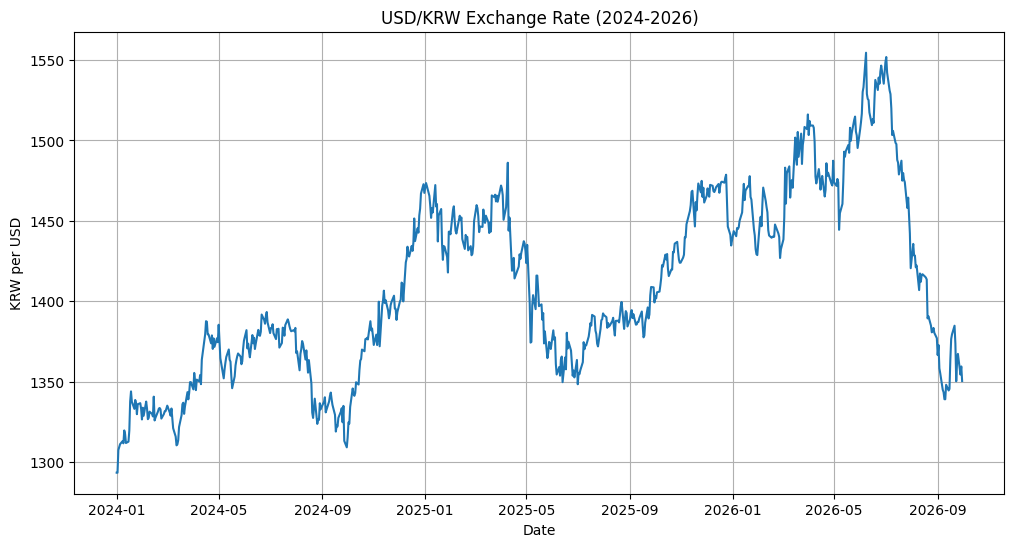

In [9]:
plt.figure(figsize=(12, 6))

plt.plot(close)

plt.title("USD/KRW Exchange Rate (2024-2026)")
plt.xlabel("Date")
plt.ylabel("KRW per USD")

plt.grid(True)
plt.show()

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

df = yf.download(
    "KRW=X",
    start="2024-01-01",
    end="2026-10-01",
    interval="1d"
)

/tmp/ipykernel_3036/3886571511.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed


In [3]:
close = df["Close"]["KRW=X"]

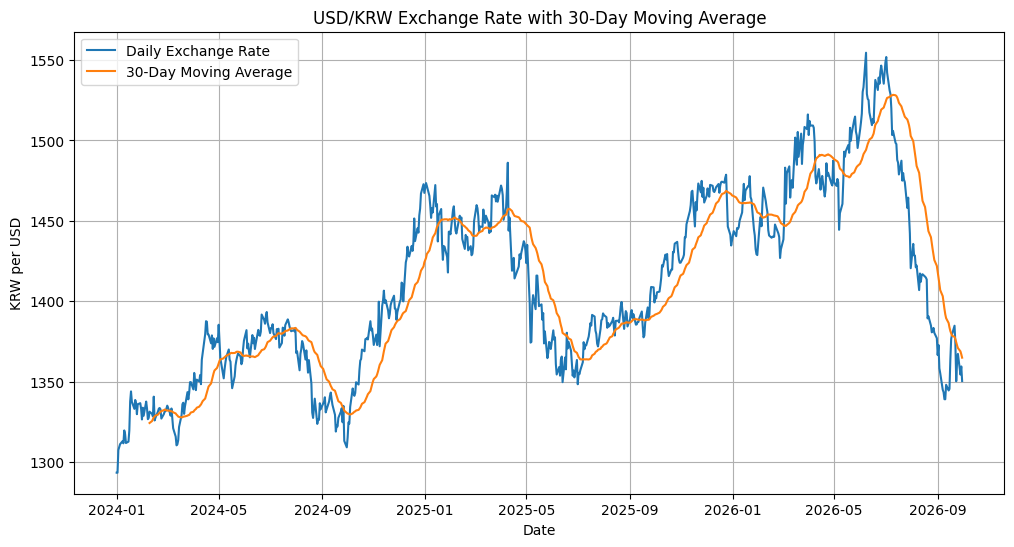

In [4]:
close = df["Close"]["KRW=X"]

moving_avg_30 = close.rolling(window=30).mean()

plt.figure(figsize=(12, 6))

plt.plot(close, label="Daily Exchange Rate")
plt.plot(moving_avg_30, label="30-Day Moving Average")

plt.title("USD/KRW Exchange Rate with 30-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("KRW per USD")
plt.legend()
plt.grid(True)

plt.show()

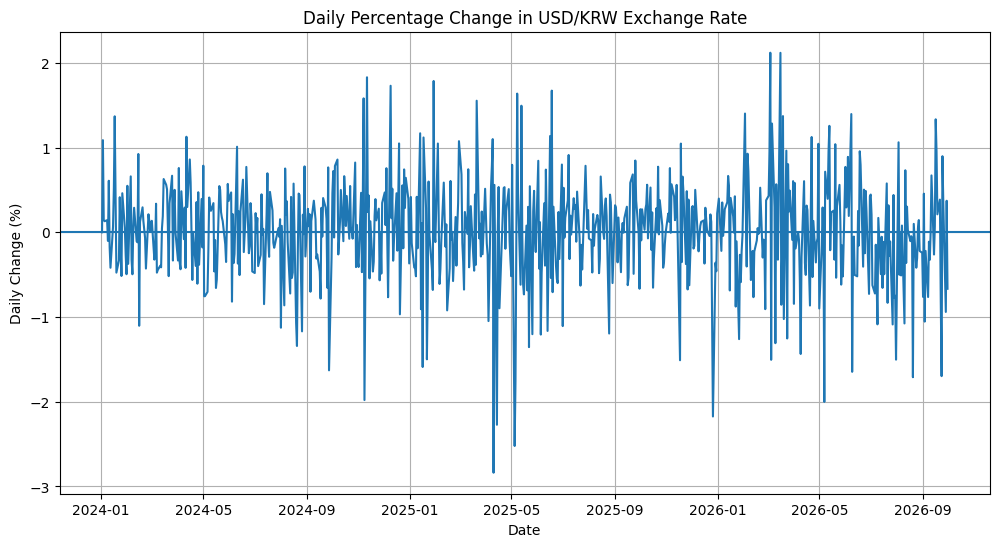

In [5]:
daily_change = close.pct_change() * 100

plt.figure(figsize=(12, 6))

plt.plot(daily_change)

plt.title("Daily Percentage Change in USD/KRW Exchange Rate")
plt.xlabel("Date")
plt.ylabel("Daily Change (%)")

plt.axhline(0)
plt.grid(True)

plt.show()

In [6]:
print("가장 큰 상승일:", daily_change.idxmax())
print("가장 큰 상승률:", daily_change.max(), "%")

print("가장 큰 하락일:", daily_change.idxmin())
print("가장 큰 하락률:", daily_change.min(), "%")

가장 큰 상승일: 2026-03-04 00:00:00
가장 큰 상승률: 2.1208126824620255 %
가장 큰 하락일: 2025-04-10 00:00:00
가장 큰 하락률: -2.8382479037736386 %


In [7]:
daily_change.abs().sort_values(ascending=False).head(10)

,KRW=X
Date,
2025-04-10,2.838248
2025-05-05,2.522469
2025-04-14,2.271975
2025-12-26,2.174253
2026-03-04,2.120813
2026-03-16,2.119575
2026-05-07,2.002090
2024-11-08,1.980289
2024-11-11,1.830797


In [8]:
top_changes = daily_change.loc[
    daily_change.abs().sort_values(ascending=False).head(10).index
]

top_changes

,KRW=X
Date,
2025-04-10,-2.838248
2025-05-05,-2.522469
2025-04-14,-2.271975
2025-12-26,-2.174253
2026-03-04,2.120813
2026-03-16,2.119575
2026-05-07,-2.002090
2024-11-08,-1.980289
2024-11-11,1.830797


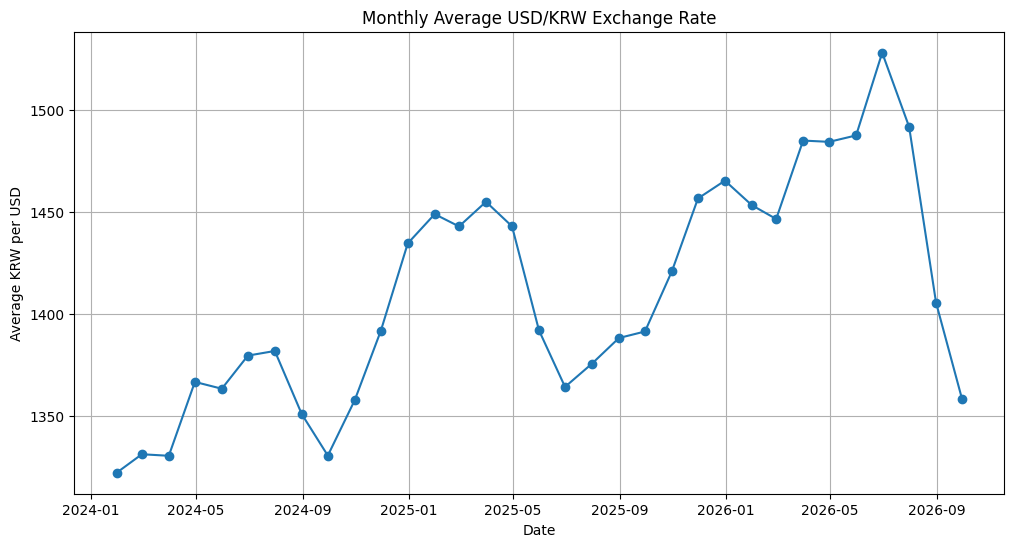

In [9]:
monthly_avg = close.resample("ME").mean()

plt.figure(figsize=(12, 6))

plt.plot(monthly_avg, marker="o")

plt.title("Monthly Average USD/KRW Exchange Rate")
plt.xlabel("Date")
plt.ylabel("Average KRW per USD")
plt.grid(True)

plt.show()

In [10]:
print("월평균 최고 월:", monthly_avg.idxmax())
print("월평균 최고 환율:", monthly_avg.max())

print("월평균 최저 월:", monthly_avg.idxmin())
print("월평균 최저 환율:", monthly_avg.min())

월평균 최고 월: 2026-06-30 00:00:00
월평균 최고 환율: 1528.0945490056818
월평균 최저 월: 2024-01-31 00:00:00
월평균 최저 환율: 1322.3034880264945


In [11]:
monthly_avg.round(2)

,KRW=X
Date,
2024-01-31,1322.30
2024-02-29,1331.36
2024-03-31,1330.60
2024-04-30,1366.80
2024-05-31,1363.45
2024-06-30,1379.69
2024-07-31,1381.96
2024-08-31,1351.03
2024-09-30,1330.70


In [12]:
Q1 = daily_change.quantile(0.25)
Q3 = daily_change.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = daily_change[
    (daily_change < lower_bound) |
    (daily_change > upper_bound)
]

print("이상치 기준 하한:", lower_bound)
print("이상치 기준 상한:", upper_bound)
print("이상치 개수:", len(outliers))

outliers

이상치 기준 하한: -1.4486527980826627
이상치 기준 상한: 1.470052824760458
이상치 개수: 26


,KRW=X
Date,
2024-09-27,-1.629152
2024-11-07,1.582006
2024-11-08,-1.980289
2024-11-11,1.830797
2024-12-09,1.730725
2025-01-16,-1.589930
2025-01-21,-1.499264
2025-01-29,1.787122
2025-03-21,1.553976


In [13]:
import os

os.makedirs("images", exist_ok=True)
os.makedirs("data", exist_ok=True)

In [14]:
df.to_csv("data/usd_krw_2024_2026.csv")

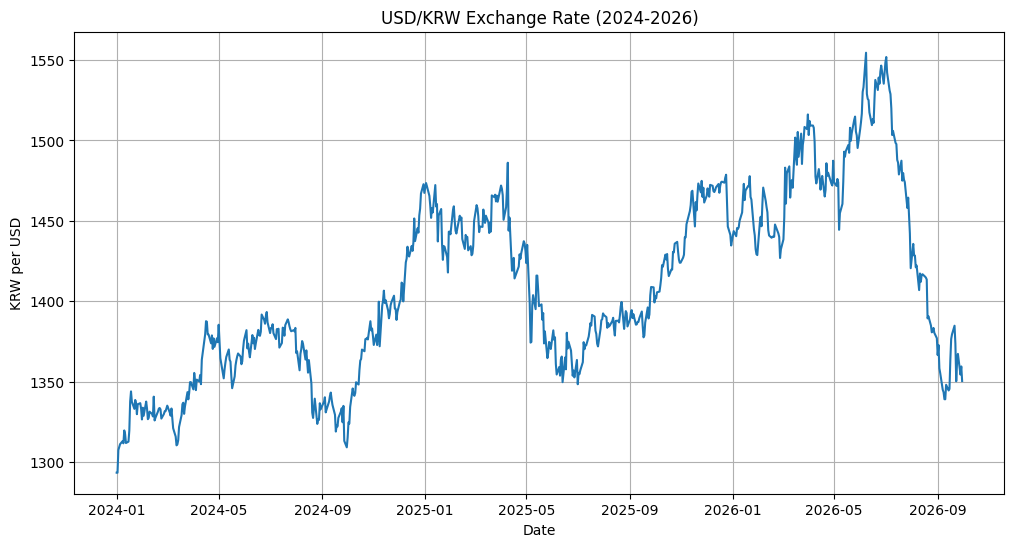

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(close)

plt.title("USD/KRW Exchange Rate (2024-2026)")
plt.xlabel("Date")
plt.ylabel("KRW per USD")
plt.grid(True)

plt.savefig("images/01_exchange_rate_trend.png", dpi=300, bbox_inches="tight")
plt.show()

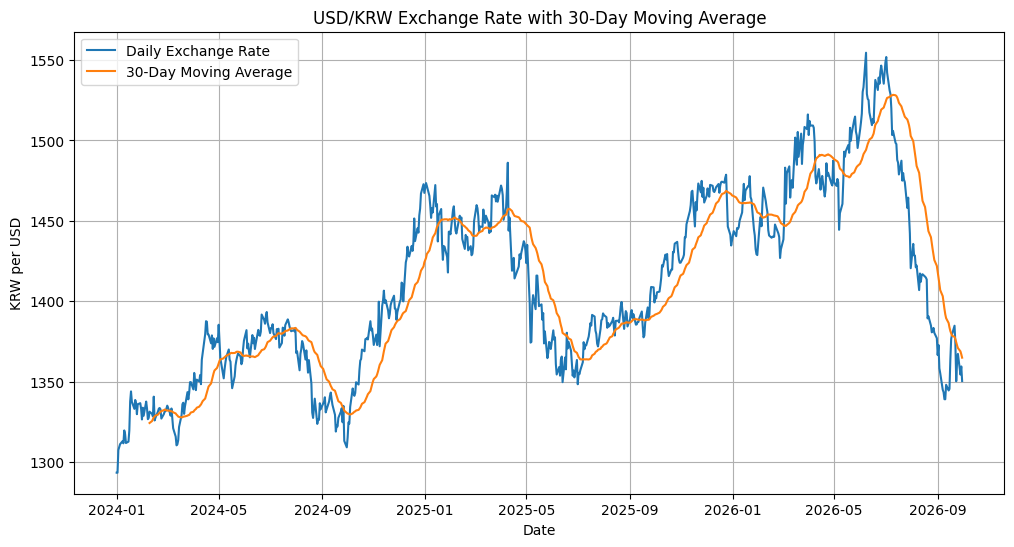

In [16]:
plt.figure(figsize=(12, 6))

plt.plot(close, label="Daily Exchange Rate")
plt.plot(moving_avg_30, label="30-Day Moving Average")

plt.title("USD/KRW Exchange Rate with 30-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("KRW per USD")
plt.legend()
plt.grid(True)

plt.savefig("images/02_moving_average.png", dpi=300, bbox_inches="tight")
plt.show()

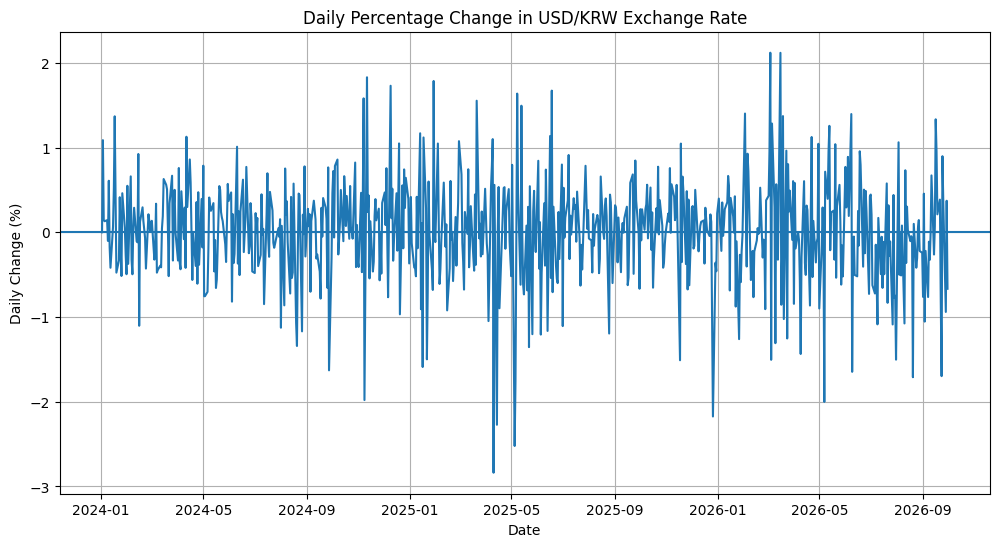

In [17]:
plt.figure(figsize=(12, 6))

plt.plot(daily_change)
plt.axhline(0)

plt.title("Daily Percentage Change in USD/KRW Exchange Rate")
plt.xlabel("Date")
plt.ylabel("Daily Change (%)")
plt.grid(True)

plt.savefig("images/03_daily_change.png", dpi=300, bbox_inches="tight")
plt.show()

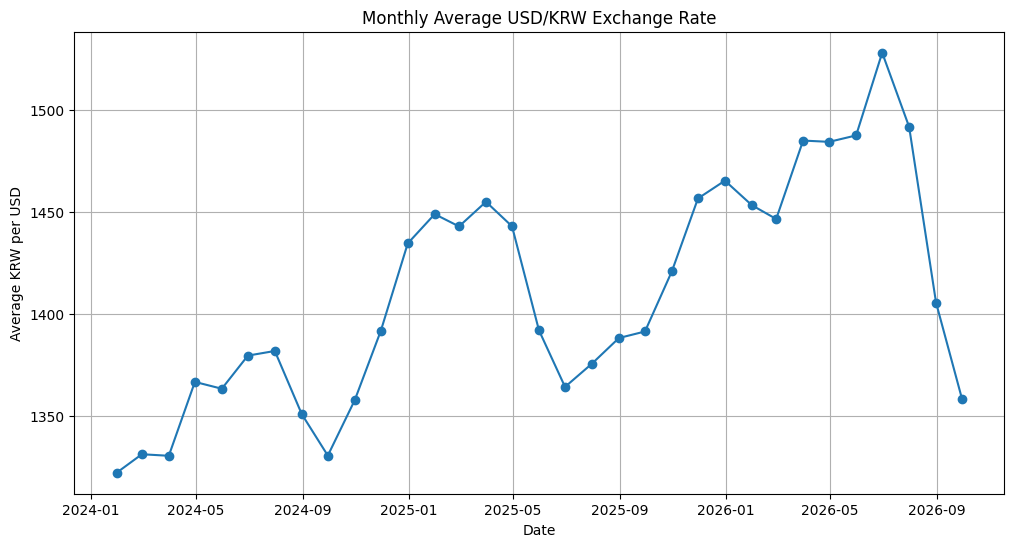

In [18]:
plt.figure(figsize=(12, 6))

plt.plot(monthly_avg, marker="o")

plt.title("Monthly Average USD/KRW Exchange Rate")
plt.xlabel("Date")
plt.ylabel("Average KRW per USD")
plt.grid(True)

plt.savefig("images/04_monthly_average.png", dpi=300, bbox_inches="tight")
plt.show()

In [19]:
report = """
# 시계열 데이터를 활용한 2024~2026년 원/달러 환율 트렌드 분석

## 1. 분석 주제 및 선정 이유

원/달러 환율은 해외여행, 수입·수출, 투자 등 다양한 경제 활동과 밀접하게 관련된 지표이다.
또한 환율은 시간에 따라 지속적으로 변화하므로 시계열 데이터의 특징을 분석하기에 적합하다.

본 분석에서는 2024년부터 2026년까지의 원/달러 환율 데이터를 활용하여
전체적인 환율의 변화 흐름을 확인하고, 이동평균과 변화율 등의 시계열 분석 기법을 통해
단기적인 변동과 장기적인 추세를 비교하고자 한다.
또한 환율 변화가 크게 나타난 시점을 찾아 데이터에서 의미 있는 패턴을 발견하는 것을 목표로 한다.

## 2. 분석 질문

1. 2024~2026년 동안 원/달러 환율은 전체적으로 어떤 상승·하락 추세를 보였는가?
2. 단기적인 환율 변동을 제거했을 때 장기적인 환율 흐름은 어떻게 나타나는가?
3. 원/달러 환율의 일별 변화율이 가장 크게 나타난 시기는 언제인가?
4. 월별 평균 환율을 비교했을 때 특정 기간에 상대적으로 높은 또는 낮은 환율 수준이 나타나는가?

## 3. 데이터 설명

- 데이터 출처: Yahoo Finance
- 티커: KRW=X
- 분석 기간: 2024-01-01 ~ 2026-09-30
- 데이터 개수: 713개
- 주요 컬럼: Open, High, Low, Close, Volume
- 주 분석 변수: Close

수집된 데이터의 각 컬럼에서 결측치는 확인되지 않았다.
주말 및 일부 휴일에는 거래 데이터가 존재하지 않아 해당 날짜의 행 자체가 포함되지 않는다.

## 4. 데이터 정제 및 분석 방법

본 분석에서는 Close 값을 주요 분석 변수로 사용하였다.

적용한 시계열 분석 기법은 다음과 같다.

1. 전체 환율 추세 확인
2. 30일 이동평균
3. 일별 변화율
4. 월별 평균 집계

결측치는 존재하지 않았다.

이상치는 일별 변화율을 기준으로 IQR 방식을 사용하여 확인하였다.
이상치 후보가 확인되더라도 실제 시장에서 발생한 급격한 환율 변동일 수 있으므로
임의로 제거하지 않고 분석에 포함하였다.

## 5. 분석 결과 및 시각화

### 5.1 전체 환율 추세

![전체 환율 추세](images/01_exchange_rate_trend.png)

2024년 초 약 1,300원 수준이던 원/달러 환율은 여러 차례 상승과 하락을 반복하였다.
2026년 중반에는 약 1,550원 수준까지 상승한 뒤,
2026년 하반기에는 약 1,350원대까지 하락하였다.

### 5.2 30일 이동평균

![30일 이동평균](images/02_moving_average.png)

30일 이동평균선은 일별 환율보다 변동폭이 작고 부드러운 형태를 보였다.
이를 통해 단기적인 변동보다 중장기적인 환율 흐름을 확인할 수 있었다.

특히 2025년 중반 이후 상승 추세가 나타났으며,
2026년 중반 이후에는 뚜렷한 하락 추세로 전환되었다.

### 5.3 일별 변화율

![일별 변화율](images/03_daily_change.png)

일별 변화율을 분석한 결과,
가장 큰 상승률은 2026년 3월 4일의 약 +2.12%였고,
가장 큰 하락률은 2025년 4월 10일의 약 -2.84%였다.

대부분의 날짜에서는 비교적 작은 범위의 변동이 나타났지만,
일부 시점에서는 상대적으로 큰 변동이 확인되었다.

### 5.4 월별 평균 환율

![월별 평균 환율](images/04_monthly_average.png)

월별 평균으로 집계했을 때 일별 변동이 완화되어
전체적인 상승과 하락 흐름이 더 명확하게 나타났다.

2024년 초에는 상대적으로 낮은 수준이었으며,
2025년 초와 2026년 중반에는 비교적 높은 환율 수준을 보였다.
이후 2026년 하반기에는 큰 폭의 하락이 나타났다.

## 6. 주요 인사이트

### 인사이트 1. 환율은 단일 방향으로 움직이지 않았다.

관찰:
분석 기간 동안 원/달러 환율은 여러 차례 상승과 하락을 반복하였다.

해석:
따라서 전체 기간을 하나의 상승 추세 또는 하락 추세로 단순화하기보다는
여러 구간으로 나누어 추세 변화를 살펴보는 것이 적절하다.

### 인사이트 2. 이동평균을 사용하면 추세 전환 시점을 더 명확하게 볼 수 있다.

관찰:
일별 환율 데이터는 변동이 많았지만,
30일 이동평균선에서는 중장기적인 상승 및 하락 흐름이 더 부드럽게 나타났다.

해석:
이동평균은 단기적인 노이즈를 줄이고 장기적인 추세를 확인하는 데 효과적이었다.

### 인사이트 3. 일부 날짜에서는 평소보다 큰 변동이 나타났다.

관찰:
가장 큰 상승률은 약 +2.12%, 가장 큰 하락률은 약 -2.84%였다.

해석:
대부분의 날짜에서는 비교적 작은 변화가 나타났지만,
일부 시점에서는 큰 폭의 움직임이 발생하였다.
이는 특정 경제·정책·시장 이벤트의 영향을 받았을 가능성이 있으나,
환율 데이터만으로 원인을 단정할 수는 없다.

## 7. 결론 및 한계점

본 분석을 통해 2024년부터 2026년까지의 원/달러 환율은
지속적인 단일 추세보다는 여러 차례의 상승과 하락 국면을 보였음을 확인하였다.

30일 이동평균을 통해 중장기적인 흐름을 확인할 수 있었고,
일별 변화율을 통해 급격한 변동이 나타난 시점을 확인할 수 있었다.
또한 월별 평균 분석을 통해 일별 변동보다 전체적인 흐름을 더 쉽게 파악할 수 있었다.

다만 본 분석은 환율 데이터만을 사용하였기 때문에
금리, 물가, 정치적 사건, 국제 금융시장 상황 등의 외부 요인을 함께 고려하지 못했다.
따라서 특정 시점의 환율 변화 원인을 직접적으로 설명하는 데에는 한계가 있다.

향후에는 미국 및 한국의 기준금리, 달러지수, 주요 경제지표 등을 함께 분석하면
보다 구체적인 원인 분석이 가능할 것이다.

## 8. AI 사용 로그

- 사용 작업: 분석 질문 구성, Python 코드 작성 보조, 시각화 코드 작성, 분석 결과 문장 정리
- 사용 이유: 코드 작성 시간 절감, 분석 방법 탐색, 보고서 표현 개선
- 검증 방법: 생성된 코드를 직접 실행하고 실제 출력값과 그래프를 확인하였다.
  또한 주요 수치는 Python 결과와 비교하여 일치 여부를 확인하였다.
  AI가 제안한 해석 중 데이터만으로 단정하기 어려운 내용은 제외하거나 한계점으로 명시하였다.
"""

with open("REPORT.md", "w", encoding="utf-8") as f:
    f.write(report)

print("REPORT.md 저장 완료")

REPORT.md 저장 완료


In [20]:
Q1 = daily_change.quantile(0.25)
Q3 = daily_change.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = daily_change[
    (daily_change < lower_bound) |
    (daily_change > upper_bound)
]

print("이상치 기준 하한:", lower_bound)
print("이상치 기준 상한:", upper_bound)
print("이상치 개수:", len(outliers))

이상치 기준 하한: -1.4486527980826627
이상치 기준 상한: 1.470052824760458
이상치 개수: 26


In [21]:
print("월평균 최고 월:", monthly_avg.idxmax())
print("월평균 최고 환율:", monthly_avg.max())

print("월평균 최저 월:", monthly_avg.idxmin())
print("월평균 최저 환율:", monthly_avg.min())

월평균 최고 월: 2026-06-30 00:00:00
월평균 최고 환율: 1528.0945490056818
월평균 최저 월: 2024-01-31 00:00:00
월평균 최저 환율: 1322.3034880264945


In [22]:
report = """# 시계열 데이터를 활용한 2024~2026년 원/달러 환율 트렌드 분석

## 1. 분석 주제 및 선정 이유

원/달러 환율은 해외여행, 수입·수출, 투자 등 다양한 경제 활동과 밀접하게 관련된 지표이다. 또한 환율은 시간에 따라 지속적으로 변화하므로 시계열 데이터의 특징을 분석하기에 적합하다.

본 분석에서는 2024년부터 2026년까지의 원/달러 환율 데이터를 활용하여 전체적인 환율의 변화 흐름을 확인하고, 이동평균과 변화율 등의 시계열 분석 기법을 통해 단기적인 변동과 장기적인 추세를 비교하고자 한다. 또한 환율 변화가 크게 나타난 시점을 찾아 데이터에서 의미 있는 패턴을 발견하는 것을 목표로 한다.

## 2. 분석 질문

1. 2024~2026년 동안 원/달러 환율은 전체적으로 어떤 상승·하락 추세를 보였는가?
2. 단기적인 환율 변동을 제거했을 때 장기적인 환율 흐름은 어떻게 나타나는가?
3. 원/달러 환율의 일별 변화율이 가장 크게 나타난 시기는 언제인가?
4. 월별 평균 환율을 비교했을 때 특정 기간에 상대적으로 높은 또는 낮은 환율 수준이 나타나는가?

## 3. 데이터 설명

- 데이터 출처: Yahoo Finance
- 티커: KRW=X
- 분석 기간: 2024-01-01 ~ 2026-09-30
- 데이터 개수: 713개
- 주요 컬럼: Open, High, Low, Close, Volume
- 주 분석 변수: Close

수집된 데이터의 각 컬럼에서 결측치는 확인되지 않았다.

주말 및 일부 휴일에는 거래 데이터가 존재하지 않아 해당 날짜의 행 자체가 포함되지 않는다. 이는 데이터 값이 비어 있는 결측치와는 구분된다.

전체 기간의 Close 기준 평균 환율은 약 1,409.62원이었고, 최소값은 약 1,293.53원, 최대값은 약 1,554.48원이었다.

## 4. 데이터 정제 및 분석 방법

본 분석에서는 일별 원/달러 환율 데이터 중 `Close` 값을 주요 분석 변수로 사용하였다.

적용한 시계열 분석 기법은 다음과 같다.

1. 전체 환율 추세 확인
2. 30일 이동평균
3. 일별 변화율
4. 월별 평균 집계

### 4.1 결측치 처리

각 컬럼의 결측치를 확인한 결과 모든 컬럼에서 결측치가 0개로 확인되었다. 따라서 별도의 결측치 대체 또는 삭제는 수행하지 않았다.

### 4.2 이상치 확인

이상치는 일별 변화율을 기준으로 IQR 방식을 사용하여 확인하였다.

IQR 기준으로 계산한 이상치 후보 범위는 다음과 같다.

- 하한: 약 -1.45%
- 상한: 약 +1.47%
- 이상치 후보 개수: 26개

해당 범위를 벗어나는 값은 통계적으로 큰 변동에 해당하지만, 환율 데이터에서는 실제 시장에서 발생한 급격한 움직임일 수 있다. 따라서 이를 단순 오류로 판단하여 제거하지 않고 분석에 포함하였다.

## 5. 분석 결과 및 시각화

### 5.1 전체 환율 추세

![전체 환율 추세](images/01_exchange_rate_trend.png)

2024년 초 약 1,300원 수준이던 원/달러 환율은 분석 기간 동안 여러 차례 상승과 하락을 반복하였다.

2024년 중반까지 환율은 점차 상승한 뒤 하반기에 하락하는 모습을 보였고, 2024년 말부터 2025년 초까지 다시 크게 상승하였다. 이후 2025년 중반에는 약 1,350원대까지 하락했으며, 이후 다시 상승하여 2026년 중반에는 1,550원 부근까지 상승하였다.

그러나 2026년 중반 이후에는 다시 큰 폭으로 하락하여 2026년 9월에는 약 1,350원 수준까지 내려왔다.

따라서 분석 기간 전체를 하나의 상승 또는 하락 추세로 보기보다는 여러 번의 추세 전환이 나타난 시계열로 해석하는 것이 적절하다.

### 5.2 30일 이동평균

![30일 이동평균](images/02_moving_average.png)

30일 이동평균선은 일별 환율보다 변동폭이 작고 부드러운 형태를 보였다.

이를 통해 일별 데이터에서 발생하는 짧은 변동을 줄이고 중장기적인 흐름을 보다 쉽게 확인할 수 있었다.

특히 2025년 중반 이후 환율의 상승 추세가 비교적 명확하게 나타났으며, 2026년 중반 이후에는 이동평균선 역시 뚜렷하게 하락하기 시작하였다.

따라서 30일 이동평균은 단기적인 노이즈를 줄이고 추세 전환 구간을 확인하는 데 유용하였다.

### 5.3 일별 변화율

![일별 변화율](images/03_daily_change.png)

일별 변화율을 계산한 결과 대부분의 날짜에서는 비교적 작은 범위의 변동이 나타났지만, 일부 날짜에서는 큰 폭의 변화가 발생하였다.

- 가장 큰 상승일: 2026년 3월 4일
- 가장 큰 상승률: 약 +2.12%
- 가장 큰 하락일: 2025년 4월 10일
- 가장 큰 하락률: 약 -2.84%

또한 절댓값 기준으로 큰 변화가 나타난 날짜들이 일부 특정 시기에 집중되는 모습을 확인할 수 있었다.

이러한 큰 변동은 경제·정책·시장 이벤트의 영향을 받았을 가능성이 있지만, 본 분석에서는 환율 데이터만 사용하였기 때문에 구체적인 원인을 직접 확인할 수는 없다.

### 5.4 월별 평균 환율

![월별 평균 환율](images/04_monthly_average.png)

일별 데이터를 월별 평균으로 집계한 결과 단기적인 변동이 완화되고 전체적인 흐름이 더 명확하게 나타났다.

월평균 환율은 다음과 같은 특징을 보였다.

- 월평균 최저 환율: 2024년 1월 약 1,322.30원
- 월평균 최고 환율: 2026년 6월 약 1,528.09원

2024년 초에는 상대적으로 낮은 환율 수준이 나타났으나, 이후 상승과 하락을 반복하며 2026년 중반에는 가장 높은 월평균 수준을 기록하였다.

이후 2026년 하반기에는 월평균 환율이 다시 크게 하락하였다.

## 6. 주요 인사이트

### 인사이트 1. 원/달러 환율은 단일한 방향으로 움직이지 않았다.

**관찰(Fact)**
2024년부터 2026년까지 원/달러 환율은 여러 차례 상승과 하락을 반복하였다. 2024년 초 약 1,300원 수준에서 시작한 환율은 2026년 중반 약 1,550원 수준까지 상승했지만, 이후 다시 약 1,350원 수준까지 하락하였다.

**해석(Interpretation)**
분석 기간 전체를 단순한 상승 또는 하락 추세로 설명하기보다는 여러 구간으로 나누어 추세 변화를 살펴보는 것이 적절하다.

### 인사이트 2. 이동평균을 활용하면 중장기적인 추세를 더 명확하게 확인할 수 있다.

**관찰(Fact)**
일별 환율 데이터에서는 짧은 기간의 상승과 하락이 빈번하게 나타났지만, 30일 이동평균선에서는 보다 부드러운 상승·하락 흐름이 나타났다.

**해석(Interpretation)**
이동평균은 단기적인 노이즈를 줄이고 중장기적인 방향성을 확인하는 데 유용하다. 특히 2026년 중반 이후에는 일별 환율뿐 아니라 30일 이동평균선에서도 하락 추세가 뚜렷하게 나타났다.

### 인사이트 3. 일부 날짜에서는 평소보다 큰 환율 변동이 발생하였다.

**관찰(Fact)**
가장 큰 상승률은 2026년 3월 4일의 약 +2.12%였고, 가장 큰 하락률은 2025년 4월 10일의 약 -2.84%였다. IQR 방식으로 이상치 후보를 확인한 결과 총 26개의 큰 변동이 확인되었다.

**해석(Interpretation)**
대부분의 날짜에서는 작은 범위의 변화가 나타났지만, 일부 시점에는 상대적으로 큰 변동이 발생하였다. 이는 특정 경제·정책·시장 이벤트의 영향을 받았을 가능성이 있으나, 환율 데이터만으로 원인을 단정할 수는 없다.

### 인사이트 4. 월 단위로 집계하면 환율 수준의 변화가 더 분명하게 나타난다.

**관찰(Fact)**
월평균 환율은 2024년 1월 약 1,322.30원으로 가장 낮았으며, 2026년 6월 약 1,528.09원으로 가장 높았다.

**해석(Interpretation)**
일별 데이터를 월 단위로 집계하면 단기적인 변동의 영향이 줄어들어 기간별 환율 수준 차이를 보다 명확하게 확인할 수 있다.

## 7. 결론 및 한계점

본 분석을 통해 2024년부터 2026년까지의 원/달러 환율은 지속적인 하나의 추세보다는 여러 차례의 상승과 하락 국면을 보였음을 확인하였다.

30일 이동평균을 통해 단기적인 노이즈를 줄이고 중장기적인 흐름을 확인할 수 있었으며, 일별 변화율 분석을 통해 급격한 변동이 발생한 날짜를 확인할 수 있었다. 또한 월별 평균 분석을 통해 일별 데이터보다 전체적인 환율 수준의 변화를 쉽게 파악할 수 있었다.

다만 본 분석에는 다음과 같은 한계가 있다.

첫째, 원/달러 환율 데이터만을 사용하였기 때문에 금리, 물가, 달러지수, 정치적 사건, 국제 금융시장 상황 등 외부 요인의 영향을 함께 분석하지 못하였다.

둘째, 특정 날짜에 큰 환율 변화가 발생하였더라도 본 분석만으로 해당 변화의 원인을 직접적으로 설명할 수 없다.

셋째, 이동평균의 기간을 30일로 설정하였기 때문에 다른 기간의 이동평균을 사용할 경우 추세 해석이 달라질 수 있다.

향후에는 한국과 미국의 기준금리, 달러지수, 물가 및 주요 경제지표를 함께 분석하여 환율 변화의 원인을 보다 구체적으로 살펴볼 수 있다.

## 8. AI 사용 로그

### 사용 작업

- 분석 주제 및 분석 질문 구성
- Python 데이터 분석 코드 작성 보조
- 결측치 및 이상치 분석 방법 탐색
- 시각화 코드 작성
- 분석 결과 해석 보조
- 보고서 문장 구성 및 표현 개선

### 사용 이유

Python 코드 작성 시간을 줄이고, 시계열 분석에 적합한 방법을 탐색하기 위해 AI를 활용하였다. 또한 분석 결과를 보다 명확하게 설명하기 위한 문장 구성에도 AI의 도움을 받았다.

### 검증 방법

AI가 제안한 코드는 Google Colab에서 직접 실행하여 오류 여부와 결과를 확인하였다.

데이터 개수, 평균, 최댓값, 최솟값, 일별 변화율, 월별 평균 등 주요 수치는 Python 실행 결과와 직접 비교하여 확인하였다.

또한 AI가 제시한 해석 중 실제 데이터만으로 확인하기 어려운 경제적 원인에 대해서는 단정적으로 작성하지 않고 가능성 또는 분석의 한계로 표현하였다."""

with open("REPORT.md", "w", encoding="utf-8") as f:
    f.write(report)

print("REPORT.md 저장 완료")

REPORT.md 저장 완료


In [24]:
%%writefile README.md
# USD/KRW Time Series Analysis

2024년 1월부터 2026년 9월까지의 원/달러 환율 데이터를 활용한 시계열 분석 프로젝트입니다.

## 분석 내용

- 전체 환율 추세 분석
- 30일 이동평균 분석
- 일별 변화율 분석
- 월별 평균 환율 분석
- IQR 기반 이상치 확인

## 데이터

- 출처: Yahoo Finance
- 티커: KRW=X
- 기간: 2024-01-01 ~ 2026-09-30
- 데이터 수: 713개

## 프로젝트 구조

usd-krw-analysis/
- data/
  - usd_krw_2024_2026.csv
- images/
  - 01_exchange_rate_trend.png
  - 02_moving_average.png
  - 03_daily_change.png
  - 04_monthly_average.png
- analysis.ipynb
- REPORT.md
- README.md
- requirements.txt

## 실행 방법

1. Python 3.10 이상의 환경을 준비합니다.
2. 필요한 라이브러리를 설치합니다.

pip install -r requirements.txt

3. analysis.ipynb 파일을 Jupyter Notebook 또는 Google Colab에서 실행합니다.

## 사용 라이브러리

- pandas
- matplotlib
- yfinance

## 참고

본 프로젝트는 교육 목적의 데이터 분석 프로젝트이며,
환율 데이터를 이용한 투자 판단을 목적으로 하지 않습니다.

Writing README.md


In [25]:
%%writefile requirements.txt
pandas
matplotlib
yfinance

Writing requirements.txt


In [26]:
import os

for root, dirs, files in os.walk("."):
    if ".config" not in root:
        level = root.replace(".", "").count(os.sep)
        indent = "    " * level
        print(f"{indent}{os.path.basename(root)}/")
        subindent = "    " * (level + 1)
        for file in files:
            print(f"{subindent}{file}")

./
    README.md
    requirements.txt
    REPORT.md
    images/
        03_daily_change.png
        02_moving_average.png
        01_exchange_rate_trend.png
        04_monthly_average.png
    data/
        usd_krw_2024_2026.csv
    sample_data/
        README.md
        anscombe.json
        mnist_test.csv
        mnist_train_small.csv
        california_housing_test.csv
        california_housing_train.csv
